# Slotline Modes (2D Cross-Section)

This notebook builds a boxed slotline cross-section (substrate + air + two PEC slot conductors), solves eigenmodes with `WaveguideModeSolver`, and plots mode fields.

In [1]:
from palacetoolkit.mode_solver import WaveguideModeSolver
from palacetoolkit.utils import view_fe_mesh_2d, view_fields_2d, write_and_finalize_gmsh
from palacetoolkit.viz import view_mesh

import gmsh
import numpy as np

In [2]:
def make_slotline_mesh(
    box_w=8.0,
    h_sub=1.0,
    h_air=3.0,
    slot_gap=0.5,
    metal_t=0.06,
    lc_bulk=0.18,
    lc_slot=0.04,
    filename=None,
):
    gmsh.initialize()
    gmsh.option.setNumber("General.Verbosity", 0)
    gmsh.model.add("slotline_modes")

    sub = gmsh.model.occ.addRectangle(-box_w / 2, -h_sub, 0, box_w, h_sub)
    air = gmsh.model.occ.addRectangle(-box_w / 2, 0.0, 0, box_w, h_air)

    left_w = (box_w - slot_gap) / 2
    right_w = left_w
    left_metal = gmsh.model.occ.addRectangle(-box_w / 2, 0.0, 0, left_w, metal_t)
    right_metal = gmsh.model.occ.addRectangle(slot_gap / 2, 0.0, 0, right_w, metal_t)

    _, outmap = gmsh.model.occ.fragment([(2, sub), (2, air), (2, left_metal), (2, right_metal)], [])
    gmsh.model.occ.remove(list(outmap[2]) + list(outmap[3]), recursive=True)
    gmsh.model.occ.synchronize()

    all_surfs = [t for _, t in gmsh.model.getEntities(2)]
    substrate_surfs = []
    air_surfs = []
    for tag in all_surfs:
        _, cy, _ = gmsh.model.occ.getCenterOfMass(2, tag)
        if cy < -1e-9:
            substrate_surfs.append(tag)
        else:
            air_surfs.append(tag)

    gmsh.model.addPhysicalGroup(2, substrate_surfs, tag=1, name="substrate")
    gmsh.model.addPhysicalGroup(2, air_surfs, tag=2, name="air")

    bnd = gmsh.model.getBoundary([(2, t) for t in substrate_surfs + air_surfs], oriented=False, combined=False)
    edge_tags = sorted({abs(t) for _, t in bnd})

    left_slot_pec = []
    right_slot_pec = []
    open_edges = []

    for et in edge_tags:
        ex, ey, _ = gmsh.model.occ.getCenterOfMass(1, et)
        on_metal_y = (-1e-6 <= ey <= metal_t + 1e-6)
        if on_metal_y and ex < -slot_gap / 2 + 1e-6:
            left_slot_pec.append(et)
        elif on_metal_y and ex > slot_gap / 2 - 1e-6:
            right_slot_pec.append(et)
        else:
            open_edges.append(et)

    if left_slot_pec:
        gmsh.model.addPhysicalGroup(1, left_slot_pec, tag=1, name="slot_pec_left")
    if right_slot_pec:
        gmsh.model.addPhysicalGroup(1, right_slot_pec, tag=2, name="slot_pec_right")
    if open_edges:
        gmsh.model.addPhysicalGroup(1, open_edges, tag=3, name="open_boundary")

    for _, ptag in gmsh.model.getEntities(0):
        x, y, _ = gmsh.model.getValue(0, ptag, [])
        near_slot = abs(x) <= (slot_gap + 1.0) and -0.2 <= y <= (metal_t + 0.4)
        gmsh.model.mesh.setSize([(0, ptag)], lc_slot if near_slot else lc_bulk)

    gmsh.model.mesh.generate(2)
    return write_and_finalize_gmsh(filename, prefix="wg_slotline_")

In [ ]:
eps_sub = 4.1
eps_air = 1.0
mu_r = 1.0
omega = 1.0

Loading mesh file: /tmp/wg_slotline_r1vf2qxf.msh
Groups to render transparent: ['air_none', 'air_plastic_enclosure']

Mesh loaded successfully with 2 cell blocks
Found 5224 triangles total
Physical group tags in mesh: {1: 'substrate', 2: 'air'}



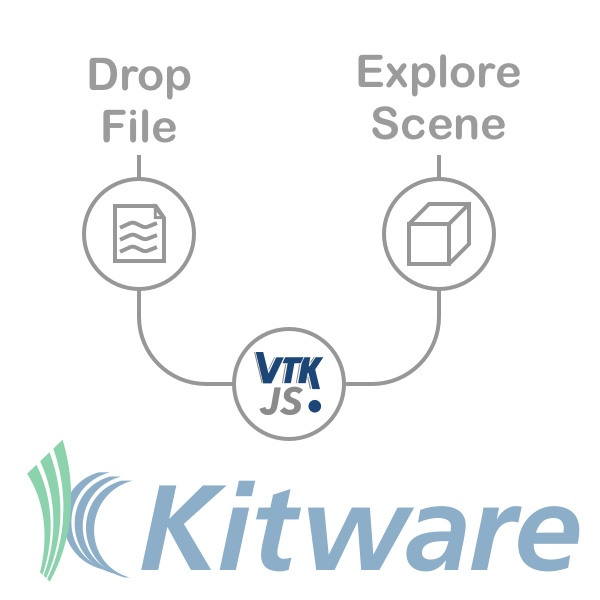

  FE spaces: ND dofs = 26424, H1 dofs = 10753, total = 37177
  Essential DOFs: ND = 336, H1 = 338, total = 674


  Solving eigenvalue problem (omega = 18, sigma = -3492.72, size = 37177)...


  Found 8 modes:
    Mode 1: kn = +5.63257464e+01 -0.00000000e+00j <-- selected
    Mode 2: kn = +5.63257413e+01 -0.00000000e+00j
    Mode 3: kn = +5.63256014e+01 -0.00000000e+00j
    Mode 4: kn = +5.63215402e+01 -0.00000000e+00j
    Mode 5: kn = +5.63156173e+01 -0.00000000e+00j
    Mode 6: kn = +5.63147912e+01 -0.00000000e+00j
    Mode 7: kn = +5.63143031e+01 -0.00000000e+00j
    Mode 8: kn = +5.63051128e+01 -0.00000000e+00j
Computed slotline modes:
  Mode  1: kn=+56.325746 -0.000000j
  Mode  2: kn=+56.325741 -0.000000j
  Mode  3: kn=+56.325601 -0.000000j
  Mode  4: kn=+56.321540 -0.000000j
  Mode  5: kn=+56.315617 -0.000000j
  Mode  6: kn=+56.314791 -0.000000j
  Mode  7: kn=+56.314303 -0.000000j
  Mode  8: kn=+56.305113 -0.000000j


In [4]:
mesh_file = make_slotline_mesh(
    box_w=8.0,
    h_sub=1.0,
    h_air=3.0,
    slot_gap=0.5,
    metal_t=0.06,
)
view_mesh(mesh_file)

mu_inv = {1: 1.0 / mu_r, 2: 1.0 / mu_r}
eps = {1: eps_sub, 2: eps_air}

# Only slot metal boundaries are PEC. Open boundaries stay non-PEC.
pec_bdr = [1, 2]

solver = WaveguideModeSolver(mesh_file, order=2, mu_inv=mu_inv, eps=eps, pec_bdr=pec_bdr)
results = solver.solve(omega, num_modes=8, mode_idx=1)

print("Computed slotline modes:")
for i, kn in enumerate(results["kn"], start=1):
    print(f"  Mode {i:2d}: kn={kn.real:+10.6f}{kn.imag:+10.6f}j")

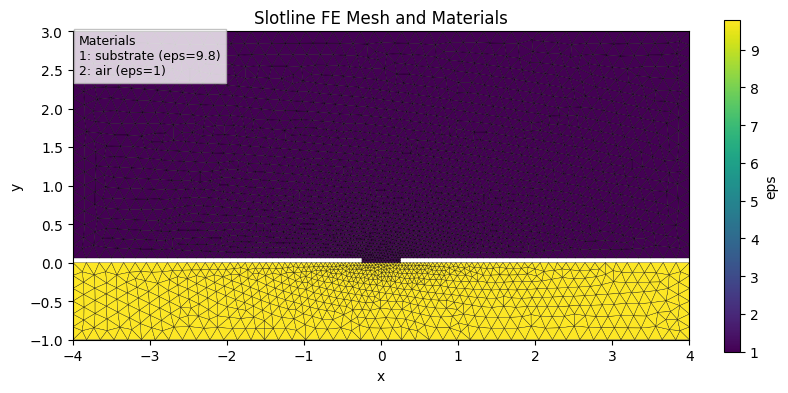

In [5]:
view_fe_mesh_2d(
    mesh_file=mesh_file,
    eps=eps,
    title="Slotline FE Mesh and Materials",
    show_edges=True,
)




MFEM Warning: 76 points were not found
 ... in function: virtual int mfem::Mesh::FindPoints(mfem::DenseMatrix&, mfem::Array<int>&, mfem::Array<mfem::IntegrationPoint>&, bool, mfem::InverseElementTransformation*)
 ... in file: /__w/PyMFEM/PyMFEM/PyMFEM/external/mfem/mesh/mesh.cpp:13515





MFEM Warning: 76 points were not found
 ... in function: virtual int mfem::Mesh::FindPoints(mfem::DenseMatrix&, mfem::Array<int>&, mfem::Array<mfem::IntegrationPoint>&, bool, mfem::InverseElementTransformation*)
 ... in file: /__w/PyMFEM/PyMFEM/PyMFEM/external/mfem/mesh/mesh.cpp:13515





MFEM Warning: 76 points were not found
 ... in function: virtual int mfem::Mesh::FindPoints(mfem::DenseMatrix&, mfem::Array<int>&, mfem::Array<mfem::IntegrationPoint>&, bool, mfem::InverseElementTransformation*)
 ... in file: /__w/PyMFEM/PyMFEM/PyMFEM/external/mfem/mesh/mesh.cpp:13515



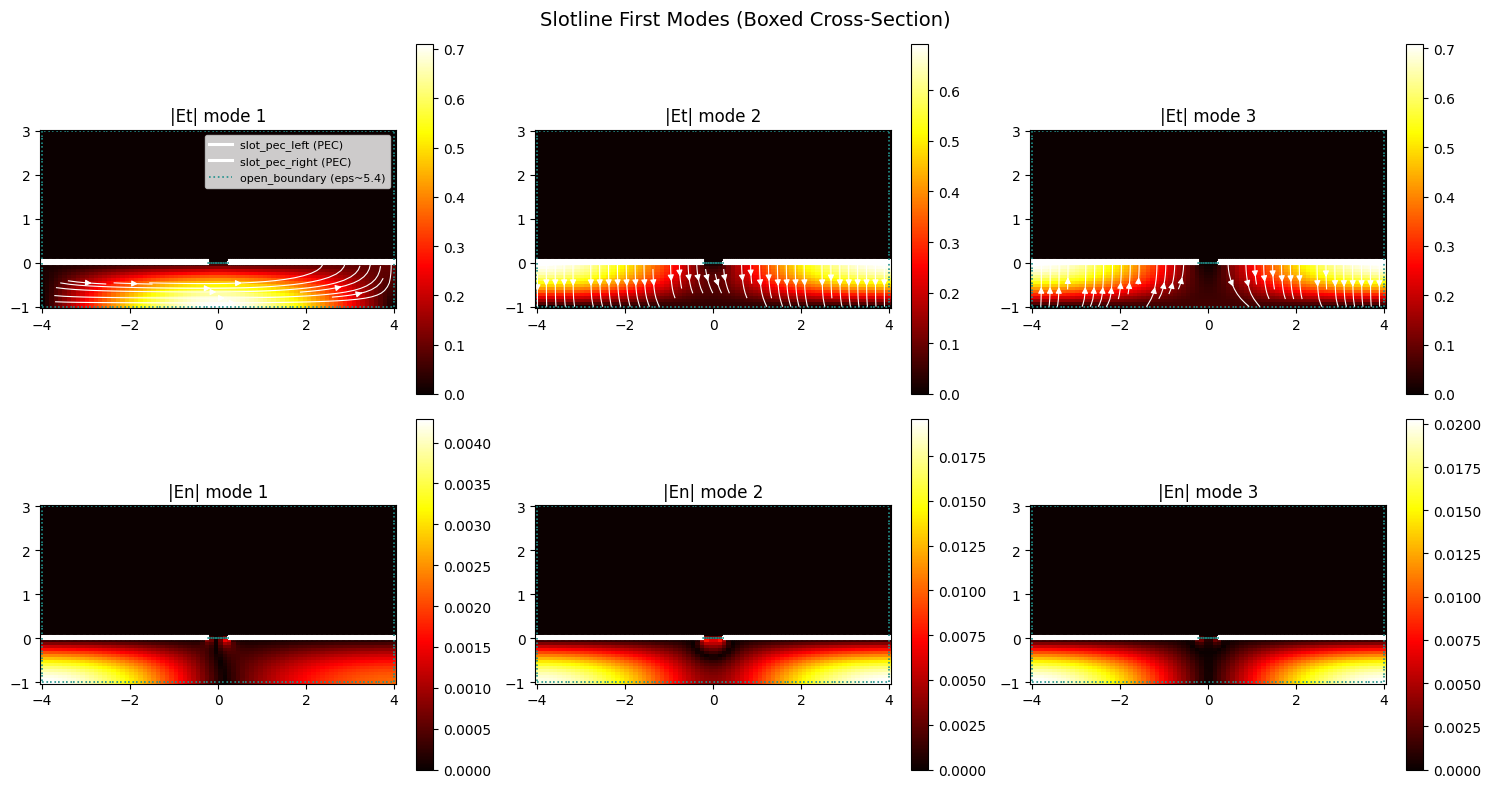

In [6]:
view_fields_2d(
    solver=solver,
    results=results,
    mesh_file=mesh_file,
    eps=eps,
    pec_bdr=pec_bdr,
    include_streamplot=True,
    streamplot_density=1.2,
    streamplot_show_arrows=True,
    streamplot_normalize=True,
    streamplot_seed_from_field=True,
    streamplot_seed_frac=0.1,
    streamplot_seed_stride=2,
    streamplot_mask_weak=True,
    streamplot_min_frac=0.1,
    num_modes=3,
    nx=80,
    ny=60,
    cmap="hot",
    title="Slotline First Modes (Boxed Cross-Section)",
)